<a href="https://colab.research.google.com/github/serli2904/Tugas-Kuliah-Teknik-Pengambilan-Sampel-dan-Wrangling/blob/main/Tugas_1_Praktikum_Serli_sri_lestari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Library yang Diperlukan**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Uload data berbentuk csv ke file Jupyter Notebook

In [ ]:
# Membaca data CSV
data = pd.read_csv('/content/data_iklim - Sheet1.csv')
# Melihat 5 data pertama
print(data.head())

  precipitation max temperature min temperature         wind  \
0   22,17864727          22,579          16,226   0,98477418   
1   10,77861942          29,369         20,2985  1,054619598   
2   9,443091888          27,384           18,62  0,999835774   
3   15,51303961         21,7585         14,9085  0,922273123   
4   15,21262902          24,568          17,651  1,078517568   

  relative humidity        solar  
0       0,949216707  12,98674041  
1       0,837694214  20,63957504  
2       0,869631027  18,48553254  
3        0,95195662  9,497525996  
4       0,927156092  15,35485704  


Ubah nama variabel

In [ ]:
data.rename(columns={'precipitation': 'Y', 'max temperature': 'X1', 'min temperature': 'X2', 'wind': 'X3', 'relative humidity': 'X4', 'solar': 'X5' }, inplace=True)

# Convert columns to numeric, handling comma as decimal separator
for col in ['Y', 'X1', 'X2', 'X3', 'X4', 'X5']:
    data[col] = data[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(data)

            Y       X1       X2        X3        X4         X5
0   22.178647  22.5790  16.2260  0.984774  0.949217  12.986740
1   10.778619  29.3690  20.2985  1.054620  0.837694  20.639575
2    9.443092  27.3840  18.6200  0.999836  0.869631  18.485533
3   15.513040  21.7585  14.9085  0.922273  0.951957   9.497526
4   15.212629  24.5680  17.6510  1.078518  0.927156  15.354857
..        ...      ...      ...       ...       ...        ...
73  12.599952  28.5500  27.6160  4.894644  0.778710  24.586383
74  15.132806  28.3940  27.4405  5.250058  0.782321  24.467849
75  10.986334  28.2970  27.3200  5.626393  0.784487  23.705266
76   9.758090  28.4465  27.4975  5.078008  0.777539  23.123691
77   8.621691  28.6175  27.6740  4.858509  0.769383  22.735279

[78 rows x 6 columns]


## Memebuat correlation plot untuk melihat antar hubungan variable


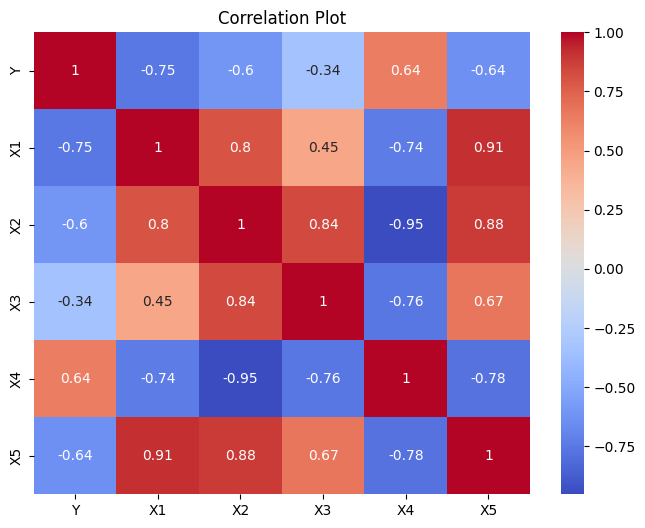

In [ ]:
# Membuat correlation plot untuk melihat hubungan antar variabel
plt.figure(figsize=(8,6))

# Membuat heatmap korelasi
sns.heatmap(data[['Y','X1','X2','X3','X4','X5']].corr(),
            annot=True,           # menampilkan nilai korelasi
            cmap='coolwarm')      # warna grafik

# Memberi judul grafik
plt.title("Correlation Plot")

# Menampilkan grafik
plt.show()

Interpretasi


*   Nilai korelasi mendekati 1 → hubungan positif kuat
*   Nilai mendekati -1 → hubungan negatif kuat
*   Nilai mendekati 0 → hubungan lemah








In [ ]:
X = data[['X1','X2','X3','X4','X5']]
Y = data['Y']

# menambahkan konstanta
X = sm.add_constant(X)

model = sm.OLS(Y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.55e-15
Time:                        04:01:57   Log-Likelihood:                -164.19
No. Observations:                  78   AIC:                             340.4
Df Residuals:                      72   BIC:                             354.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.9870     16.485     -0.545      0.5

1. Uji Simultan (Uji F)

Prob (F-statistic)

Interpretasi:

Jika
p-value < 0.05


- variabel X1–X5 secara bersama berpengaruh terhadap Y

2.
 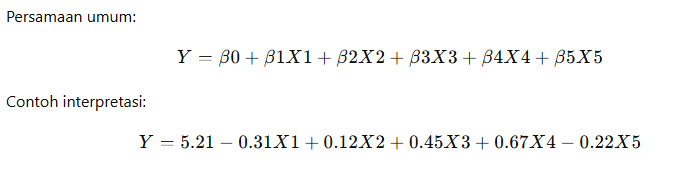

3. Uji Parsial (Uji t)

P>|t|

interpretasi:

| p-value | Kesimpulan          |
| ------- | ------------------- |
| < 0.05  | variabel signifikan |
| > 0.05  | tidak signifikan    |

4. Koefisien Determinasi

R-squared

Interpretasi

Jika R² = 0.65

➡ 65% variasi precipitation dijelaskan oleh variabel:

*   temperature
*   wind
*   humidity
*   solar

 4 Uji Asumsi Klasik

1. Normalitas Residual

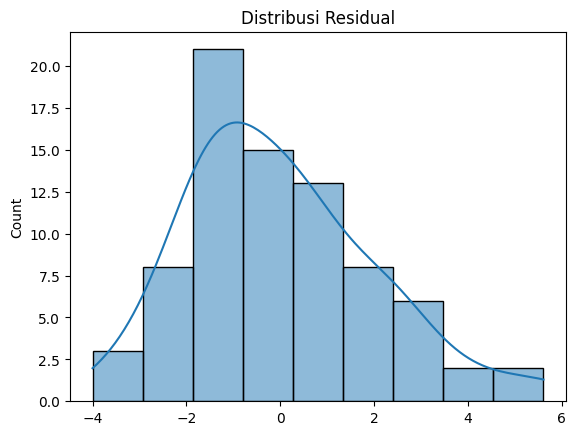

ShapiroResult(statistic=np.float64(0.9658793950238578), pvalue=np.float64(0.034639058388638753))

In [ ]:
residual = model.resid

sns.histplot(residual, kde=True)
plt.title("Distribusi Residual")
plt.show()

stats.shapiro(residual)

Interpretasi:

p-value > 0.05

- residual normal



2. Multikolinearitas (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)

  variable          VIF
0    const  4961.823030
1       X1    11.342047
2       X2    40.057239
3       X3     7.473819
4       X4    14.505695
5       X5    12.501233


Interpretasi:

| VIF  | Kesimpulan                  |
| ---- | --------------------------- |
| < 10 | tidak ada multikolinearitas |



3. Heteroskedastisitas

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan

test = het_breuschpagan(residual, X)

labels = ['LM Statistic','LM-Test p-value','F-Statistic','F-Test p-value']

print(dict(zip(labels,test)))

{'LM Statistic': np.float64(12.444484190281013), 'LM-Test p-value': np.float64(0.029179650329912744), 'F-Statistic': np.float64(2.7335697099873797), 'F-Test p-value': np.float64(0.02563931403257371)}


Interpretasi:

p-value > 0.05

- tidak terjadi heteroskedastisitas

4. Autokorelasi

In [ ]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residual)
print("Durbin Watson:", dw)

Durbin Watson: 1.7830776392551193


Interpretsi:

| DW        | Kesimpulan             |
| --------- | ---------------------- |
| sekitar 2 | tidak ada autokorelasi |


**Tugas 1 buatlah model regresi menggunakan data dibawah ini**

https://docs.google.com/spreadsheets/d/15Gsb-I5JgvndJ2MPAjlbIonVTjvPXKr0uovce2bksAI/edit?usp=sharing

1. Ganti nama variabel menjadi

   Y  : precipitation
   
   X1 : max temperature
   
   X2 : min temperature

   X3 : wind

   X4 : relative humidity

   X5 : solar

2. Buat Correlation Plot dan interpretasikan

3. Buat Model regresi, selidiki model, uji simultan, uji parsial dan koefisien determinasi

4. Cek ke 4 asumsi, dan interpretasikan

Dikerjakan di lab, dan di kumpul di simpel.ith.ac.id